In [1]:
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

In [2]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [3]:
def hypothesis_reference_distance(hypothesis, reference):
    """
    Calculate the edit distance between a hypothesis list and a reference list.
    
    This computes the minimum number of operations (insertions, deletions, or substitutions)
    needed to transform the hypothesis into the reference.
    
    Args:
        hypothesis: The list to be evaluated
        reference: The gold standard list to compare against
        
    Returns:
        int: The edit distance score (lower is better, 0 means identical)
    """
    # Create a matrix of size (len(hypothesis) + 1) x (len(reference) + 1)
    dp = [[0 for _ in range(len(reference) + 1)] for _ in range(len(hypothesis) + 1)]
    
    # Initialize the first row and column
    for i in range(len(hypothesis) + 1):
        dp[i][0] = i  # Cost of deleting i elements from hypothesis
    for j in range(len(reference) + 1):
        dp[0][j] = j  # Cost of inserting j elements from reference
    
    # Fill the rest of the matrix
    for i in range(1, len(hypothesis) + 1):
        for j in range(1, len(reference) + 1):
            if hypothesis[i-1] == reference[j-1]:
                # No operation needed if elements match
                dp[i][j] = dp[i-1][j-1]
            else:
                # Take the minimum cost operation
                dp[i][j] = 1 + min(
                    dp[i-1][j],    # deletion (remove from hypothesis)
                    dp[i][j-1],    # insertion (add from reference)
                    dp[i-1][j-1]   # substitution (replace hypothesis element with reference element)
                )
    
    return dp[len(hypothesis)][len(reference)]

In [4]:
def get_wnr(x):
    if x['samples_type'] == 'dropout' and x['sample_idx'] > 0:
        return {
            'wnr_last': [None] * len(x['message']),
            'wnr_min': [None] * len(x['message']),
        }

    processed_messages = [
        [
            tok.lemma_
            for tok in s
            if tok.pos_ in ["NOUN", "ADJ", "VERB", "ADV", "PROPN", "NUM", "PRON", "ADP"]
        ]
        for s in nlp.pipe(x["message"])
    ]

    wnr_last = [hypothesis_reference_distance(m, processed_messages[i-1]) / len(processed_messages[i-1]) if i > 0 else None for i, m in enumerate(processed_messages)]
    wnr_min = [min([hypothesis_reference_distance(m, processed_messages[j]) / len(processed_messages[j]) for j in range(0, i)]) if i > 0 else None for i, m in enumerate(processed_messages)]

    return {
        'wnr_last': wnr_last,
        'wnr_min': wnr_min,
    }

In [45]:
from PIL import Image

def stitch_images_horizontally(image_list, spacing=0):
    """
    Combine multiple PIL images into a single horizontal image.
    
    Args:
        image_list (list): List of PIL Image objects to stitch together
        spacing (int, optional): Number of pixels between images. Defaults to 0.
        
    Returns:
        PIL.Image.Image: A new image containing all input images stitched horizontally
    """
    if not image_list:
        return None
    
    # Check if all elements are PIL Images
    if not all(isinstance(img, Image.Image) for img in image_list):
        raise TypeError("All elements in image_list must be PIL Image objects")
    
    # Get dimensions
    widths, heights = zip(*(img.size for img in image_list))
    
    # Calculate the size of the output image
    total_width = sum(widths) + spacing * (len(image_list) - 1)
    max_height = max(heights)
    
    # Create a new image with white background
    stitched_image = Image.new('RGB', (total_width, max_height), (255, 255, 255))
    
    # Paste images side by side
    x_offset = 0
    for img in image_list:
        stitched_image.paste(img, (x_offset, 0))
        x_offset += img.width + spacing
    
    return stitched_image

# Example usage:
# image_files = ["image1.jpg", "image2.jpg", "image3.jpg"]
# images = [Image.open(file) for file in image_files]
# combined_image = stitch_images_horizontally(images, spacing=10)
# combined_image.save("combined_image.jpg")

In [24]:
df_list = list()
for file in Path("../pixtral-eval-results").glob("tangrams*.json"):
    samples_type, listener_type = re.search(r"tangrams-samples=(\w+)-listener=(\w+)", file.name).groups()
    with open(file) as f:
        data = json.load(f)

    for k, v in data.items():
        gameid, trial_idx, sample_idx = re.search(r"([^_]+)_trialidx=(\d+)_sampleidx=(\d+)", k).groups()
        dropout_proportion = {0: 0.2, 1: 0.4, 2: 0.6, 3: 0.8}[int(sample_idx) % 4] if int(sample_idx) > 0 else 0

        message = v[0]['game']['trials'][-1]['message']
        denom = sum([np.exp(v) for v in v[0]['listener_probs'].values()])
        listener_probs = {k: np.exp(v) / denom for k, v in v[0]['listener_probs'].items()}
        selection_prob = listener_probs[v[0]['game']['trials'][-1]['selection']]
        target_prob = listener_probs[v[0]['game']['trials'][-1]['target']]

        df_list.append({
            'gameid': gameid,
            'trial_idx': int(trial_idx),
            'sample_idx': int(sample_idx),
            'dropout_proportion': dropout_proportion if samples_type == 'dropout' else None,
            'num_words': len(message.split()),
            'samples_type': "sampled" if samples_type == 'model' else "ablated",
            'listener_type': listener_type,
            'message': message,
            'target': v[0]['game']['trials'][-1]['target'],
            'selection': v[0]['game']['trials'][-1]['selection'],
            'selection_prob': selection_prob,
            'target_prob': target_prob,
            'correct': v[0]['game']['trials'][-1]['correct'],
            'context': ','.join(sorted(v[0]['game']['context'])),
        })

df = pd.DataFrame(df_list)

In [25]:
blocks_df = df.sort_values(['trial_idx']).groupby(['listener_type', 'samples_type', 'gameid', 'target', 'sample_idx', 'context']).agg({
    'trial_idx': list,
    'correct': list,
    'num_words': list,
    'selection_prob': list,
    'target_prob': list,
    'dropout_proportion': list,
    'message': list,
    'selection': list,
}).reset_index()

blocks_df['block_idx'] = blocks_df.apply(lambda x: np.arange(len(x['trial_idx'])), axis=1)

In [9]:
blocks_df[['wnr_last', 'wnr_min']] = blocks_df.apply(get_wnr, axis=1, result_type='expand')

In [26]:
samples_df = blocks_df.explode(['trial_idx', 'correct', 'num_words', 'selection_prob', 'target_prob', 'dropout_proportion', 'message', 'selection', 'block_idx']) # , 'wnr_last', 'wnr_min'

In [27]:
# samples_df.wnr_last = samples_df.wnr_last.astype(float)
# samples_df.wnr_min = samples_df.wnr_min.astype(float)
samples_df.target_prob = samples_df.target_prob.astype(float)
samples_df.selection_prob = samples_df.selection_prob.astype(float)
samples_df.dropout_proportion = samples_df.dropout_proportion.astype(float)
samples_df.block_idx = samples_df.block_idx.astype(int)
samples_df.num_words = samples_df.num_words.astype(int)

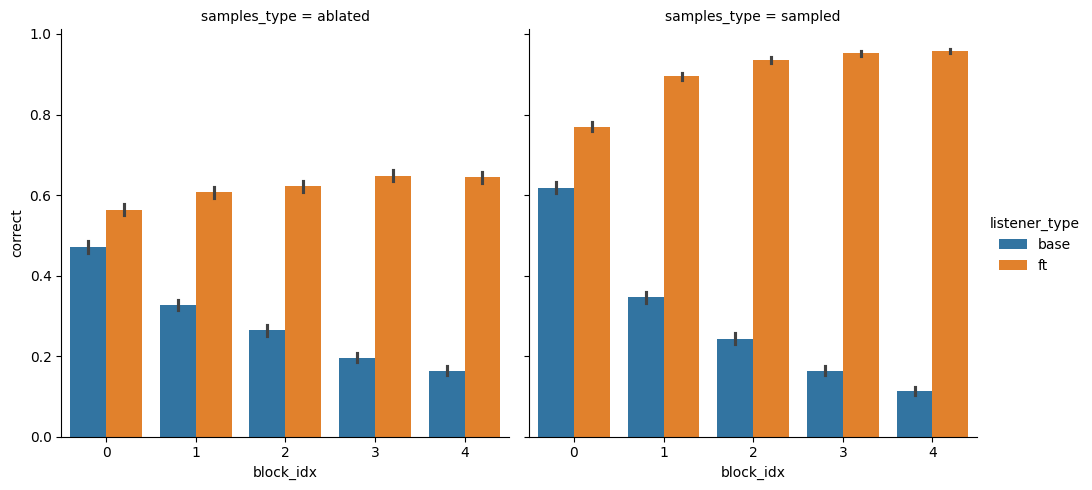

In [28]:
sns.catplot(data=samples_df, x='block_idx', y='correct', col='samples_type', hue='listener_type', kind='bar')

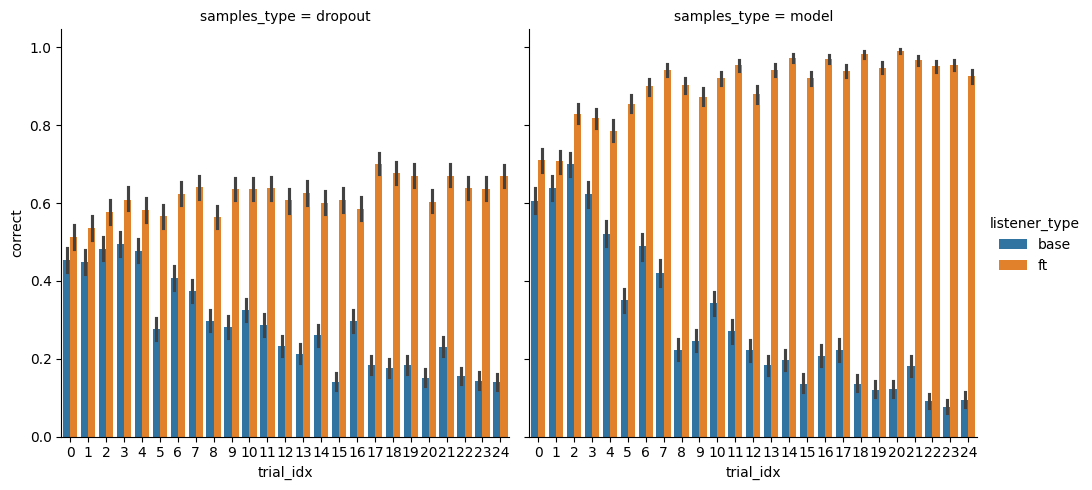

In [22]:
sns.catplot(data=samples_df, x='trial_idx', y='correct', col='samples_type', hue='listener_type', kind='bar')

(0.0, 4.0)

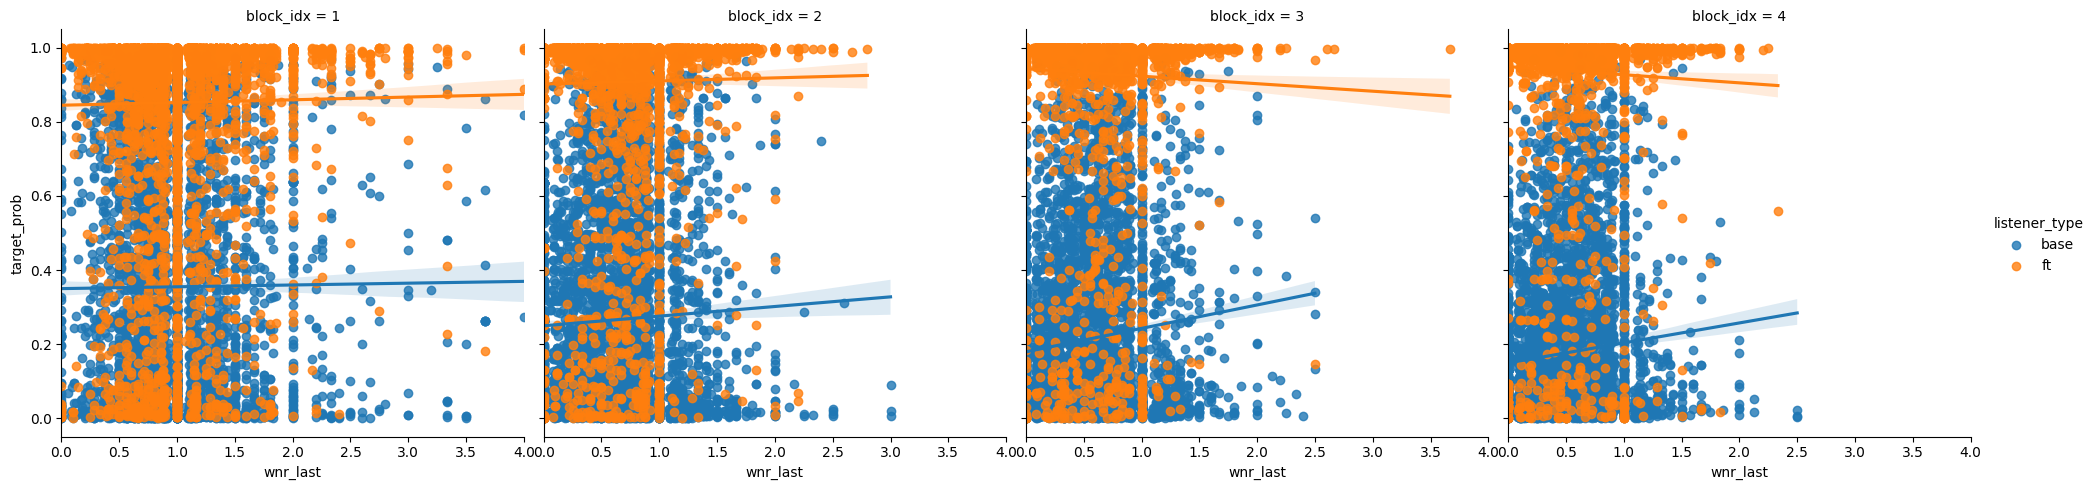

In [12]:
sns.lmplot(data=samples_df[(~samples_df.wnr_last.isnull())], x='wnr_last', y='target_prob', col='block_idx', hue='listener_type')
plt.xlim(0, 4)

(0.0, 4.0)

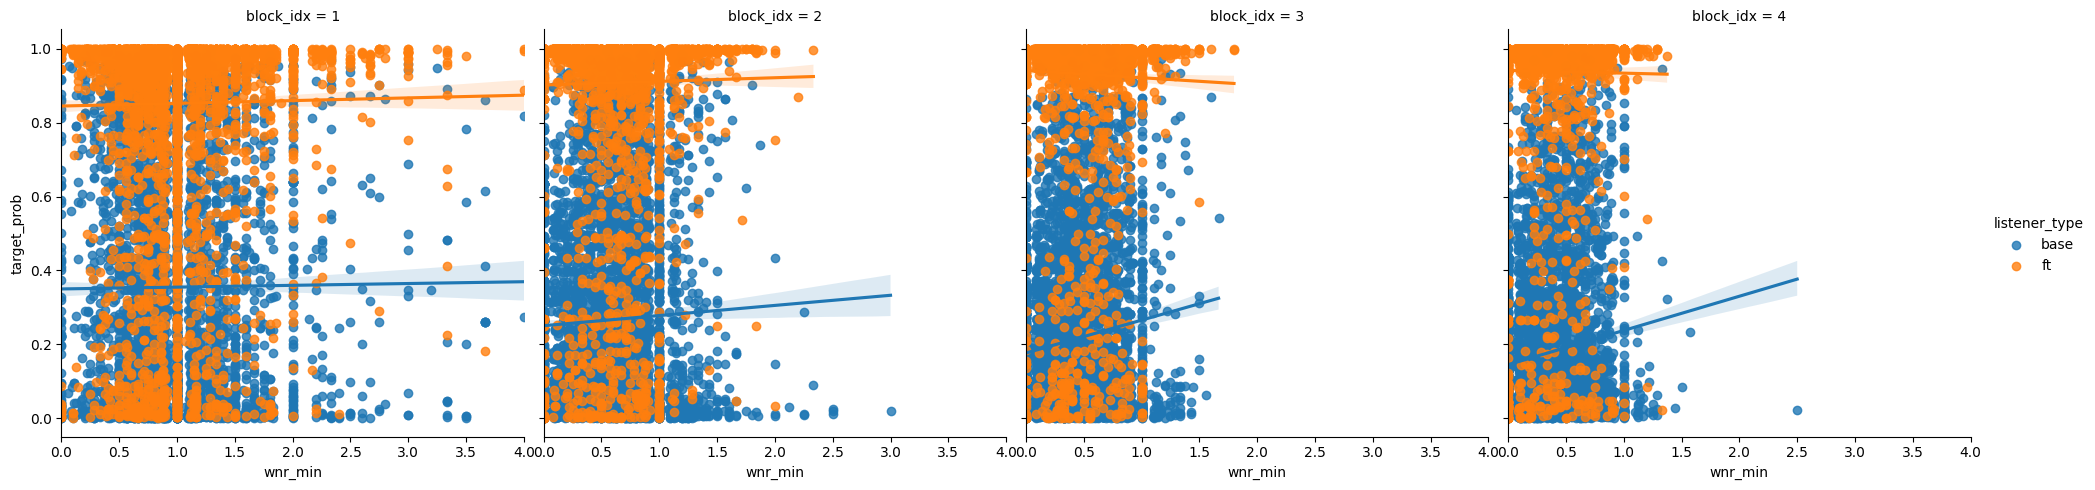

In [13]:
sns.lmplot(data=samples_df[(~samples_df.wnr_min.isnull())], x='wnr_min', y='target_prob', col='block_idx', hue='listener_type')
plt.xlim(0, 4)

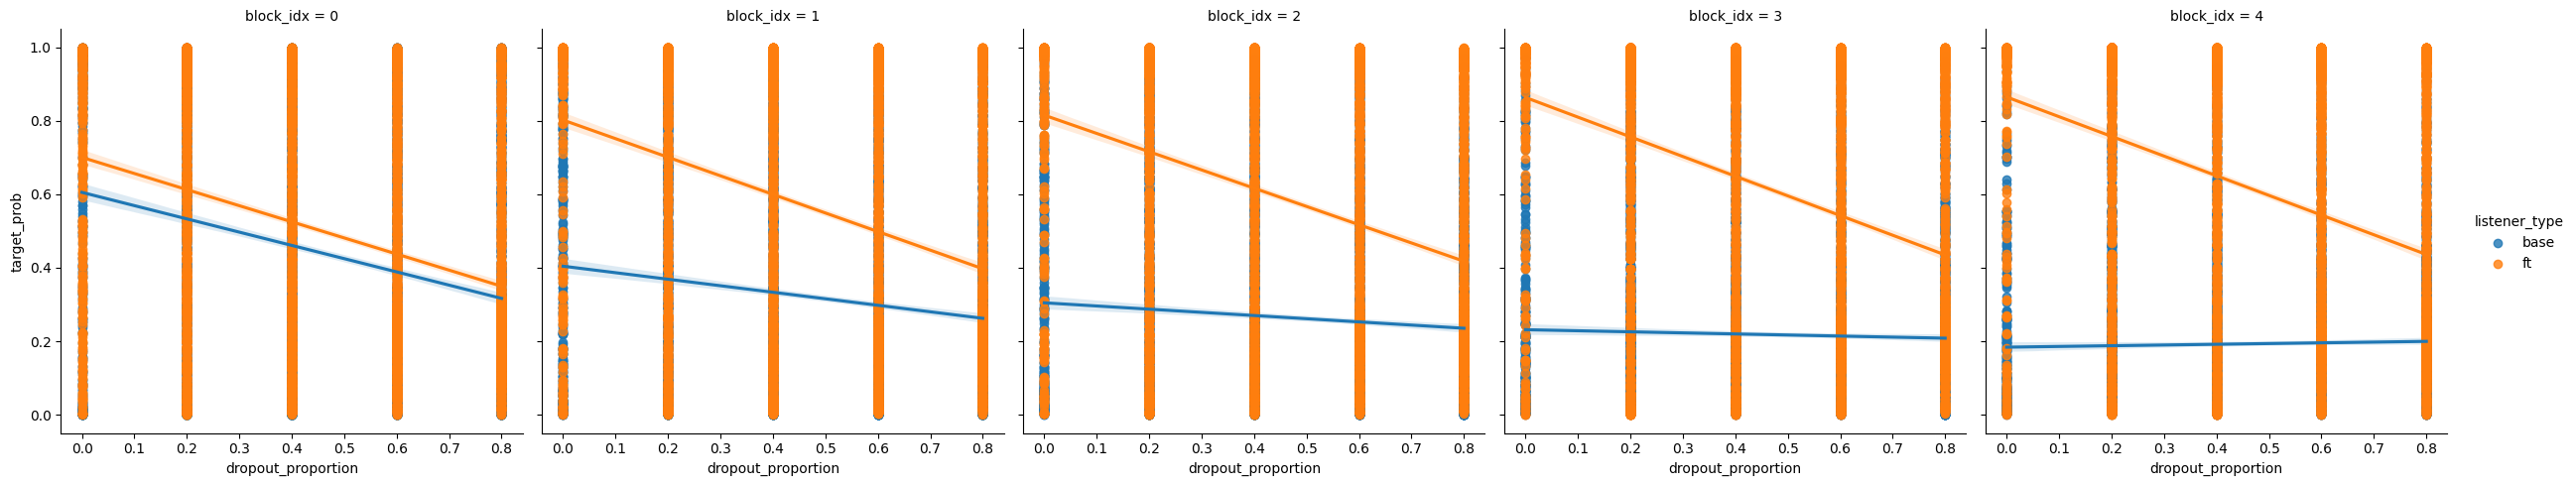

In [ ]:
sns.lmplot(data=samples_df[samples_df.samples_type == 'dropout'], x='dropout_proportion', y='target_prob', col='block_idx', hue='listener_type', )

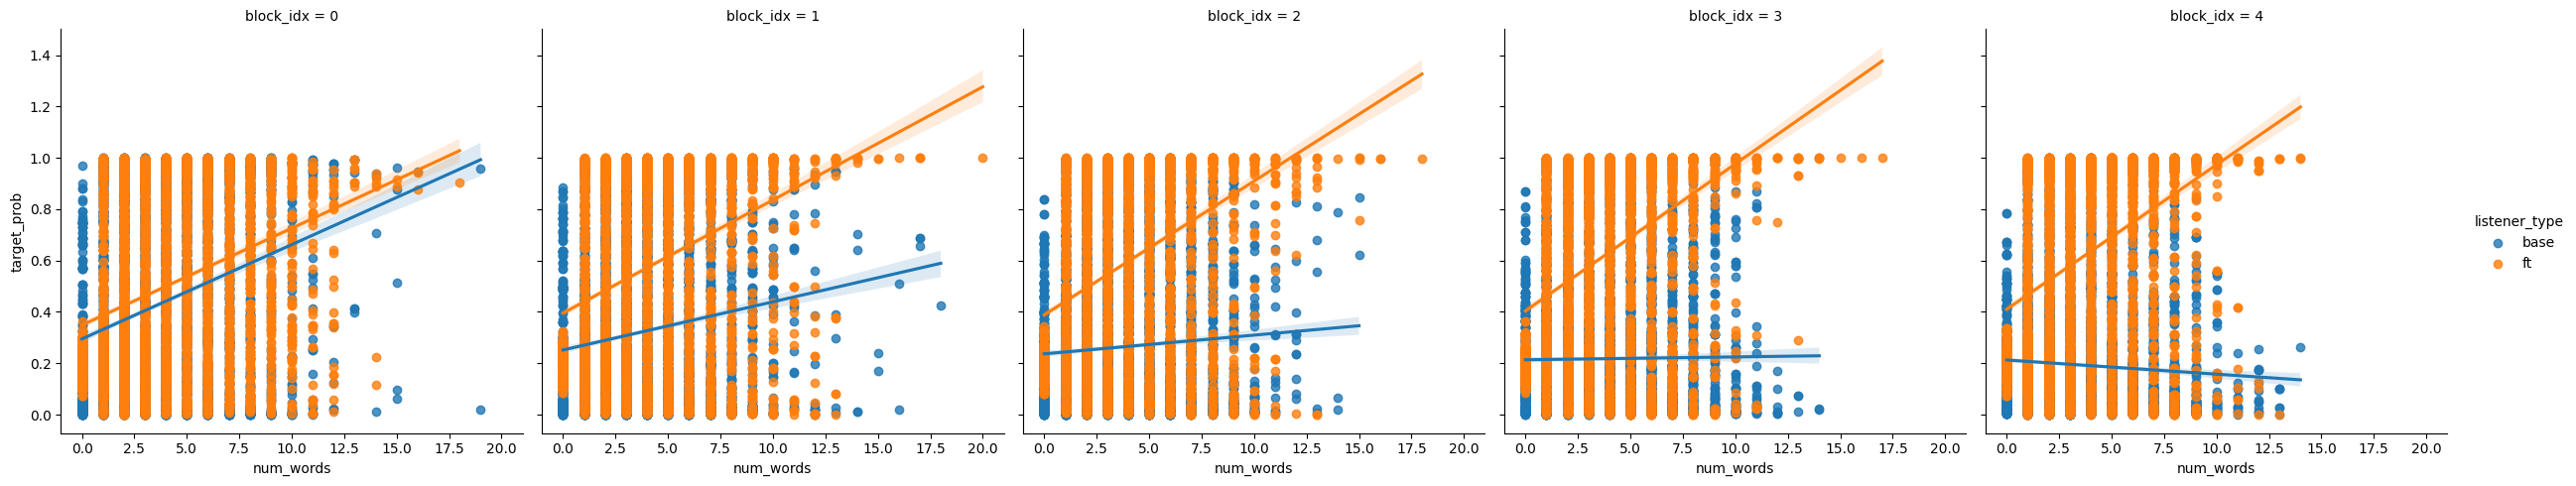

In [34]:
sns.lmplot(data=samples_df[samples_df.samples_type == 'dropout'], x='num_words', y='target_prob', col='block_idx', hue='listener_type')

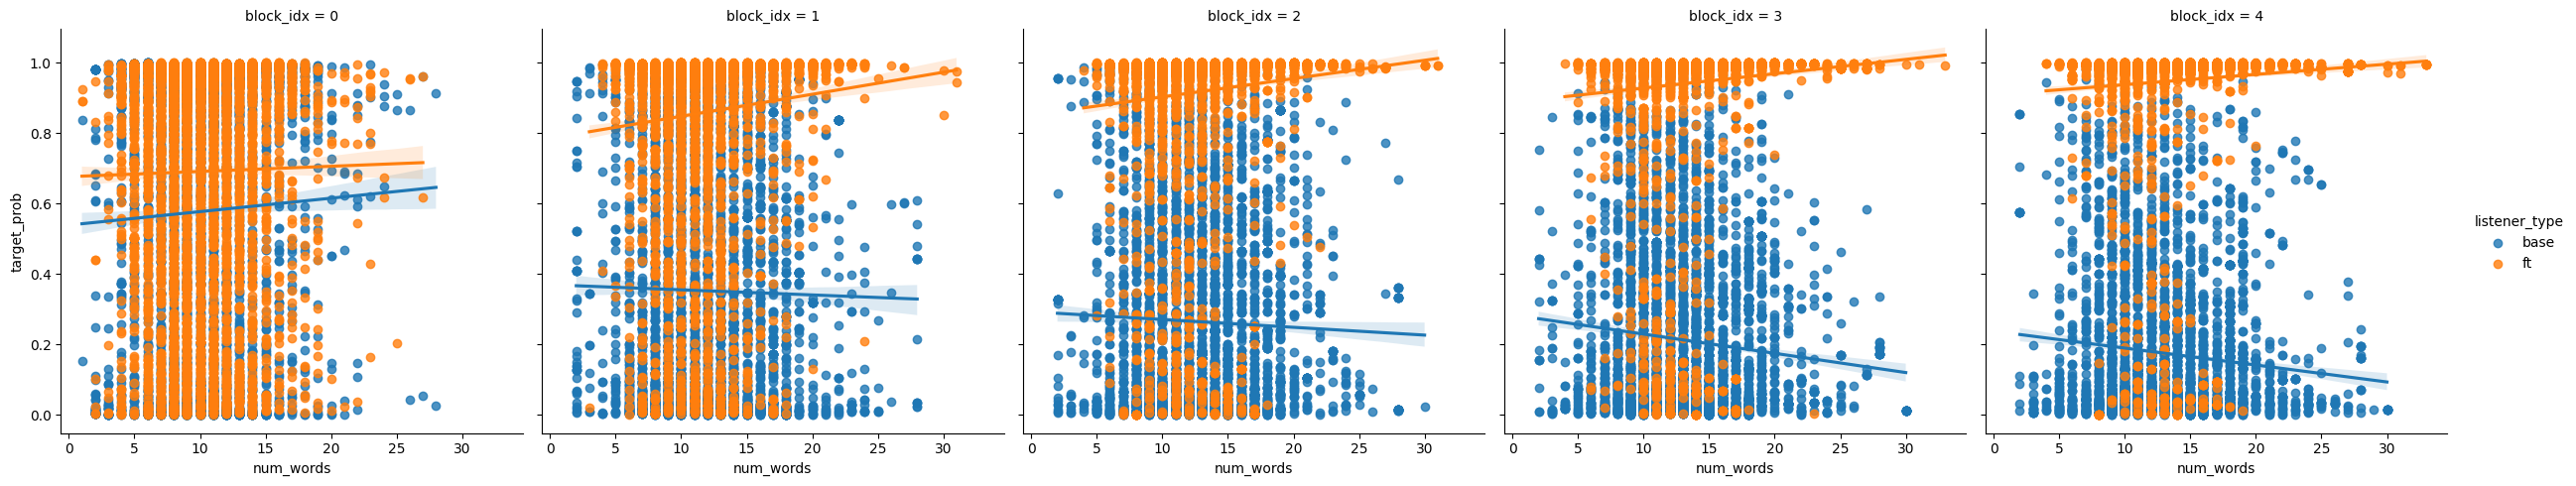

In [35]:
sns.lmplot(data=samples_df[samples_df.samples_type == 'model'], x='num_words', y='target_prob', col='block_idx', hue='listener_type')

In [25]:
samples_df.gameid.unique()

array(['3ary6q5mdMWTh8EFJ', '5SkNPcH4uWWhoHzD2', '6oDZZokaTPbFbFyxq',
       '7ECfJqZSjjsz8oBCM', '8RoqYM3LR5QpJwzT5', 'AN9gPwv399LTgFC6i',
       'AxdskuDf9fuWiKCFc', 'C4BE3Bcky8iq2Dip5', 'CNAiKT7Av6y2oHwvy',
       'Cf5fFT4QPbByXSB5s', 'FvSgGZcaE85QgqXam', 'GJ9acNnSs4GtJvHLn',
       'GehtkSFKYT3GHP8dZ', 'Gk2kEho6sFLNkapKy', 'KCgt2qJ7K79xySLRm',
       'KJeMAhHTjaCs9sMpk', 'KtmmR6GzmqDdjN8LM', 'M5ui5knKYuwwDLr9i',
       'McsJhwH9t5b9tLX8Z', 'MigdGFwdtEjpqF2kr', 'NBDRu7N7ZS8cWHsSp',
       'NovnByQTkpGZEsomb', 'NsiBXAJpHkx8tDfWh', 'Pf3ccYhQKq2Fd22zv',
       'PtNMvuqEYD8d8uyms', 'QT3vWwrgmdivMgG4h', 'QhN3JTKAjnfQb6DXS',
       'RgiXtnKrXiiHQZpcz', 'SjEpBubywARjBE4T6', 'TBL7t2i2TYAWFdDTj',
       'Xmax5bZuQDhSqPMLq', 'YBd2adukpGvYkJvtG', 'YjNav28ajaN8MaDor',
       'ZcWh2SAbYaKsBjERa', 'aELmSMWu4ggF3hihD', 'd8wBFJSAzTXrSi2Ro',
       'dLCiwM5JkBvYfx83i', 'dxkfkqCnTmaN3ATNk', 'eopF622nhHAfYBAbw',
       'fRYo7vsJGdw2KQnMc', 'h3DszyAzWvDeNDqFi', 'jE8JMgZXZtXkxhbZL',
       'jKTvqGPmLEET

In [61]:
samples_df[
    (samples_df.listener_type == "ft")
    & (samples_df.samples_type == "dropout")
    & (samples_df.gameid == "SjEpBubywARjBE4T6")
    & (samples_df.target == "page-F.png")
    & (samples_df.block_idx == 3)
][
    [
        "message",
        "selection_prob",
        "target_prob",
        "dropout_proportion",
        "correct",
        "target",
        "selection",
    ]
].sort_values(
    "dropout_proportion"
)

,message,selection_prob,target_prob,dropout_proportion,correct,target,selection
11960,Person sitting down.,0.988042,0.988042,0.0,True,page-F.png,page-F.png
11963,sitting down.,0.970811,0.970811,0.2,True,page-F.png,page-F.png
11967,Person sitting down.,0.988042,0.988042,0.2,True,page-F.png,page-F.png
11971,Person down.,0.806922,0.806922,0.2,True,page-F.png,page-F.png
11975,Person sitting down.,0.988042,0.988042,0.2,True,page-F.png,page-F.png
11972,sitting,0.969842,0.969842,0.4,True,page-F.png,page-F.png
11968,Person down.,0.806922,0.806922,0.4,True,page-F.png,page-F.png
11964,Person sitting,0.981870,0.981870,0.4,True,page-F.png,page-F.png
11976,Person,0.953696,0.953696,0.4,True,page-F.png,page-F.png
11973,,0.294850,0.157822,0.6,False,page-F.png,page7-36.png


In [55]:
ctx = samples_df[
    (samples_df.listener_type == "ft")
    & (samples_df.samples_type == "dropout")
    & (samples_df.gameid == "SjEpBubywARjBE4T6")
    & (samples_df.block_idx == 0)
][
    [
        "message",
        "selection_prob",
        "target_prob",
        "dropout_proportion",
        "correct",
        "target",
        "selection",
        'context'
    ]
].sort_values(
    "dropout_proportion"
).iloc[0].context.split(',')

print(ctx)

['page-F.png', 'page7-145.png', 'page7-36.png', 'page7-41.png', 'page8-156.png']


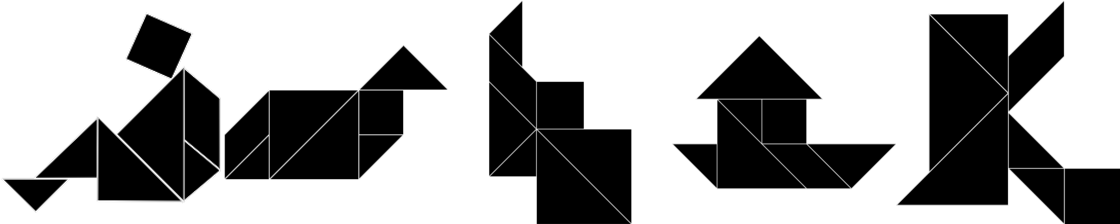

In [58]:
stitch_images_horizontally([Image.open(f"../square-black-imgs/{img}") for img in ctx])

In [64]:
samples_df[
    (samples_df.listener_type == "ft")
    & (samples_df.samples_type == "model")
    & (samples_df.gameid == "SjEpBubywARjBE4T6")
    & (samples_df.target == "page-F.png")
    & (samples_df.block_idx == 3)
][
    [
        "message",
        "selection_prob",
        "target_prob",
        "dropout_proportion",
        "correct",
        "target",
        "selection",
    ]
].sort_values(
    "dropout_proportion"
)

,message,selection_prob,target_prob,dropout_proportion,correct,target,selection
16840,"""A figure sitting with legs crossed, a square ...",0.998233,0.998233,NaN,True,page-F.png,page-F.png
16841,"""A square body with triangles forming legs and...",0.998467,0.998467,NaN,True,page-F.png,page-F.png
16842,"""A figure resembling a person sitting with leg...",0.998674,0.998674,NaN,True,page-F.png,page-F.png
16843,"""It looks like someone sitting with a square b...",0.997749,0.997749,NaN,True,page-F.png,page-F.png
16844,"""It resembles a person sitting with legs cross...",0.998949,0.998949,NaN,True,page-F.png,page-F.png
16845,"""It looks like a person sitting with legs cros...",0.997570,0.997570,NaN,True,page-F.png,page-F.png
16846,"""It looks like a figure sitting down with its ...",0.995979,0.995979,NaN,True,page-F.png,page-F.png
16847,"""A figure resembling a person sitting with leg...",0.998579,0.998579,NaN,True,page-F.png,page-F.png
16848,"""It resembles a person sitting with legs cross...",0.998949,0.998949,NaN,True,page-F.png,page-F.png
16849,"""A figure with a large triangle head and small...",0.998181,0.998181,NaN,True,page-F.png,page-F.png
